In [1]:
import pandas as pd

In [3]:
df = pd.read_csv("mabel.txt", header=None, on_bad_lines='skip', encoding='utf8')

In [4]:
df=df.drop(0)
df.columns=['Date','Chat']
Message=df["Chat"].str.split("-",n=1,expand=True)
df["Time"]=Message[0]
Message1=Message[1].str.split(":",n=1,expand=True)
df["Name"]=Message1[0]
df["Chat"]=Message1[1]
df=df[["Date","Time","Name","Chat"]]
df

,Date,Time,Name,Chat
1,05/12/19,1:42 pm,Mabel Infoziant,Hi this is Mabel we just spoke
2,05/12/19,1:42 pm,Mabel Infoziant,What’s your full name
3,05/12/19,1:42 pm,AR❤,Ramisha Rani K
4,05/12/19,1:42 pm,Mabel Infoziant,Ok
5,05/12/19,1:42 pm,Mabel Infoziant,ramisharanik@gmail.com
6,05/12/19,1:43 pm,Mabel Infoziant,Your email Id?
7,05/12/19,1:43 pm,AR❤,Yes Mam
8,05/12/19,1:43 pm,Mabel Infoziant,I will send 2 abstracts for u to start working
9,05/12/19,1:43 pm,AR❤,Yeah mam
10,05/12/19,1:43 pm,Mabel Infoziant,Give me the list that u have too


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 1 to 52
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    52 non-null     object
 1   Time    52 non-null     object
 2   Name    52 non-null     object
 3   Chat    52 non-null     object
dtypes: object(4)
memory usage: 1.8+ KB


In [9]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

In [10]:
dataset=df

In [11]:
dataset.dropna(inplace=True)

In [12]:
sid = SentimentIntensityAnalyzer()

In [13]:
senti=sid.polarity_scores(dataset['Chat'][4])

In [14]:
senti

{'neg': 0.0, 'neu': 0.0, 'pos': 1.0, 'compound': 0.296}

In [15]:
 def sentimentalAnalysis(data,columnname):
        
        #downloading vader_lexicon for the process
        import matplotlib.pyplot as plt
        import seaborn as sns
        "Importing Necessary Packeage"
        from nltk.sentiment.vader import SentimentIntensityAnalyzer
        sid = SentimentIntensityAnalyzer()
        
        "Deleting null pr empty value"
        data.dropna(inplace=True)
        
        "Checking for a comment"
        #sid.polarity_scores(data[columnname][93])
        
        "Creating respective columns"
        
        data['scores'] = data[columnname].apply(lambda commentText: sid.polarity_scores(commentText))
        data['compound']  = data['scores'].apply(lambda score_dict: score_dict['compound'])
        data['Negtive']  = data['scores'].apply(lambda score_dict: score_dict['neg'])
        data['Postive']  = data['scores'].apply(lambda score_dict: score_dict['pos'])
        data['Neutral']  = data['scores'].apply(lambda score_dict: score_dict['neu'])
        
        "Creating final pos or neg using compound score"
        data['comp_score'] = data['compound'].apply(lambda c: 'pos' if c >=0 else 'neg')
        plt.clf()
        #comp=sns.countplot(x = 'comp_score', hue = 'Name', data = data, palette = 'magma')
        #comp.figure.savefig("date_charts.png")
        "Checking how many pos and neg"
        posneg=pd.DataFrame(data['comp_score'].value_counts())
        return posneg,data
    

In [16]:
pos,data_Senti=sentimentalAnalysis(dataset,columnname='Chat')

<Figure size 640x480 with 0 Axes>

In [17]:
data_Senti

,Date,Time,Name,Chat,scores,compound,Negtive,Postive,Neutral,comp_score
1,05/12/19,1:42 pm,Mabel Infoziant,Hi this is Mabel we just spoke,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos
2,05/12/19,1:42 pm,Mabel Infoziant,What’s your full name,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos
3,05/12/19,1:42 pm,AR❤,Ramisha Rani K,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos
4,05/12/19,1:42 pm,Mabel Infoziant,Ok,"{'neg': 0.0, 'neu': 0.0, 'pos': 1.0, 'compound...",0.2960,0.000,1.000,0.000,pos
5,05/12/19,1:42 pm,Mabel Infoziant,ramisharanik@gmail.com,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos
6,05/12/19,1:43 pm,Mabel Infoziant,Your email Id?,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos
7,05/12/19,1:43 pm,AR❤,Yes Mam,"{'neg': 0.0, 'neu': 0.27, 'pos': 0.73, 'compou...",0.4019,0.000,0.730,0.270,pos
8,05/12/19,1:43 pm,Mabel Infoziant,I will send 2 abstracts for u to start working,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos
9,05/12/19,1:43 pm,AR❤,Yeah mam,"{'neg': 0.0, 'neu': 0.312, 'pos': 0.688, 'comp...",0.2960,0.000,0.688,0.312,pos
10,05/12/19,1:43 pm,Mabel Infoziant,Give me the list that u have too,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos


In [18]:
pos

,count
comp_score,
pos,50
neg,2


In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [20]:
tfidf=TfidfVectorizer(max_df=0.95,min_df=2,stop_words='english')
dtm=tfidf.fit_transform(df["Chat"])

In [29]:
from sklearn.decomposition import NMF
nmf_model=NMF(n_components=5,random_state=42)
nmf_model.fit(dtm)

C:\Users\Windows\.conda\envs\maskenv\lib\site-packages\sklearn\decomposition\_nmf.py:289: FutureWarning: The 'init' value, when 'init=None' and n_components is less than n_samples and n_features, will be changed from 'nndsvd' to 'nndsvda' in 1.1 (renaming of 0.26).
  warnings.warn(


In [23]:
for index,topic in enumerate(nmf_model.components_):
    results=([tfidf.get_feature_names()[i] for i in topic.argsort()[-10:]])
    print(results)

['project', 'finiliaze', 'sure', 'soon', 'hi', 'free', 'abstract', 'read', 'yeah', 'mam']
['free', 'finiliaze', 'details', 'ask', 'abstracts', 'number', 'yeah', 'send', 'mam', 'ok']
['meet', 'phone', 'students', 'ask', 'office', 'details', 'vignesh', 'abstracts', 'number', 'send']
['ask', 'abstracts', 'meet', 'phone', 'students', 'hi', 'know', 'office', 'just', 'tomorrow']
['ask', 'abstracts', 'yeah', 'details', 'share', 'meet', 'let', 'sure', 'soon', 'thinking']


In [24]:
topic_results=nmf_model.transform(dtm)
df["Topic"]=topic_results.argmax(axis=1)


In [25]:
df

,Date,Time,Name,Chat,scores,compound,Negtive,Postive,Neutral,comp_score,Topic
1,05/12/19,1:42 pm,Mabel Infoziant,Hi this is Mabel we just spoke,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos,3
2,05/12/19,1:42 pm,Mabel Infoziant,What’s your full name,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos,0
3,05/12/19,1:42 pm,AR❤,Ramisha Rani K,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos,0
4,05/12/19,1:42 pm,Mabel Infoziant,Ok,"{'neg': 0.0, 'neu': 0.0, 'pos': 1.0, 'compound...",0.2960,0.000,1.000,0.000,pos,1
5,05/12/19,1:42 pm,Mabel Infoziant,ramisharanik@gmail.com,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos,0
6,05/12/19,1:43 pm,Mabel Infoziant,Your email Id?,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos,0
7,05/12/19,1:43 pm,AR❤,Yes Mam,"{'neg': 0.0, 'neu': 0.27, 'pos': 0.73, 'compou...",0.4019,0.000,0.730,0.270,pos,0
8,05/12/19,1:43 pm,Mabel Infoziant,I will send 2 abstracts for u to start working,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos,2
9,05/12/19,1:43 pm,AR❤,Yeah mam,"{'neg': 0.0, 'neu': 0.312, 'pos': 0.688, 'comp...",0.2960,0.000,0.688,0.312,pos,0
10,05/12/19,1:43 pm,Mabel Infoziant,Give me the list that u have too,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos,0


In [26]:
df["Topic"].value_counts()

Topic
0    30
2    11
1     5
3     4
4     2
Name: count, dtype: int64

In [34]:
#!pip install wordCloud

In [31]:
flirt_count = (df[["Date","Time","Name","Chat"]] == 1).sum()
total = len(df)
flirt_percentage = (flirt_count / total) * 100
print("Flirt Percentage:", round(flirt_percentage, 2))

Flirt Percentage: Date    0.0
Time    0.0
Name    0.0
Chat    0.0
dtype: float64


In [35]:
dataset=df
from wordcloud import WordCloud
from nltk.corpus import stopwords
import nltk
import matplotlib.pyplot as plt
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Windows\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

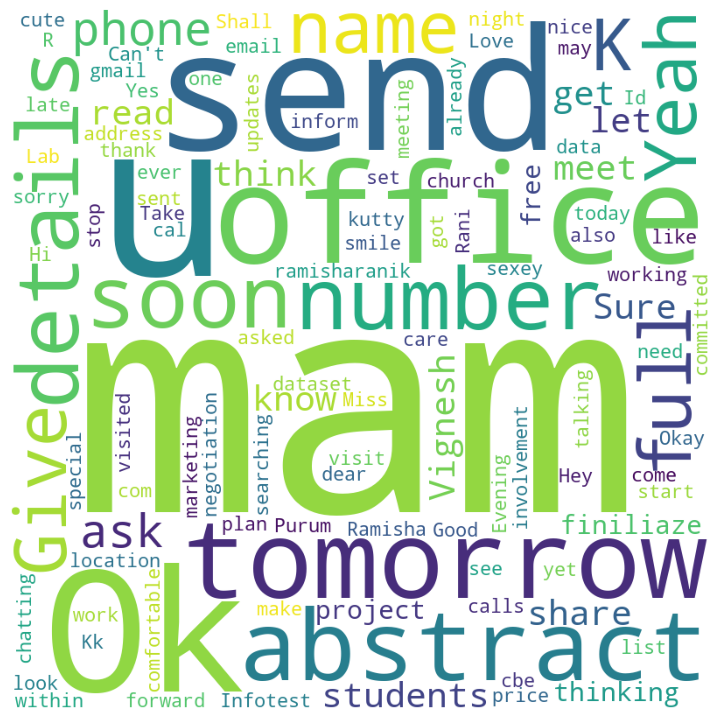

Successfully created


In [36]:
comment_words = []
stoplist = stopwords.words('english')
stoplist.extend(['omitted', 'voice','missed','call','video','deleted','media','message'])
wordcloudss="This function saves image"
dataset.index=range(dataset.shape[0])
for i in range(1,len(dataset)): 
    comment_words.append(dataset['Chat'][i])
    vv=" ".join(comment_words)          
    wordcloud = WordCloud(width = 800, height = 800, 
                                background_color ='white', 
                                      stopwords = stoplist, 
                                      min_font_size = 10).generate(vv)         
plt.figure(figsize = (9, 7), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off") 
plt.tight_layout(pad = 0) 
plt.savefig('wordcloud.PNG')
plt.show() 
print("Successfully created")
wordcloudss="This function saves image"


,Date,Chat,Flirt_Score,Flirt_Percentage,Flirt_Type
0,05/12/19,Love chatting with you❤️.,2.636900,100.00%,Flirty ❤️
1,09/12/19,You are so cute😍.,2.000000,76.53%,Flirty ❤️
2,09/12/19,You are special to me❤️ call u soon,1.401900,54.50%,Flirty ❤️
3,09/12/19,I like talking to you😘,1.361200,53.00%,Flirty ❤️
4,05/12/19,Sure kutty sexey.,1.318200,51.41%,Flirty ❤️
5,05/12/19,Can't stop thinking about you😘,1.223500,47.92%,Normal
6,18/12/19,Hey dear❤️,1.000000,39.69%,Normal
7,12/12/19,Miss you already,0.846900,34.05%,Normal
8,09/12/19,Ok mam thank u,0.571900,23.92%,Normal
9,05/12/19,Sure mam. Soon I will share details wit,0.542300,22.83%,Normal



===== SUMMARY =====
         Metric  Value
 Total Messages  52.00
Average Flirt %  16.56
    Max Flirt % 100.00
    Min Flirt %   0.00


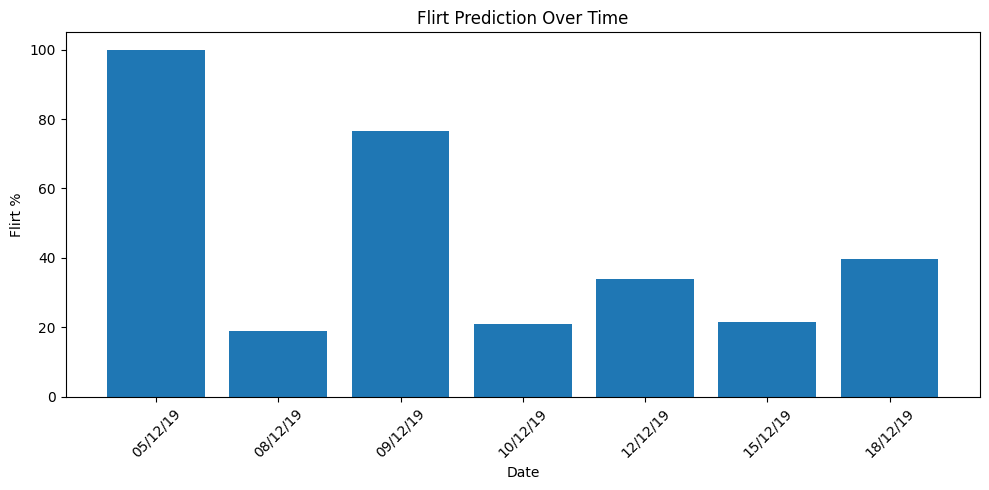

In [41]:
import matplotlib.pyplot as plt
# Flirt keywords
flirt_words = ["love", "miss", "cute", "sweet","sexey","Free", "😘", "😍", "❤️", "😉"]
# Function
def flirt_score(text):
    text = str(text)
    sentiment = sid.polarity_scores(text)['compound']
    keyword_score = sum(1 for word in flirt_words if word in text.lower())
    return sentiment + keyword_score
# Apply scoring
df["Flirt_Score"] = df["Chat"].apply(flirt_score)
# Normalize
df["Flirt_Percentage"] = (
    (df["Flirt_Score"] - df["Flirt_Score"].min()) /
    (df["Flirt_Score"].max() - df["Flirt_Score"].min() + 1e-5)
) * 100

df["Flirt_Percentage"] = df["Flirt_Percentage"].round(2)

# Add Label
df["Flirt_Type"] = df["Flirt_Percentage"].apply(
    lambda x: "Flirty ❤️" if x > 50 else "Normal"
)

#FINAL CLEAN TABLE
final_df = df[["Date", "Chat", "Flirt_Score", "Flirt_Percentage", "Flirt_Type"]]

# Sort nicely
final_df = final_df.sort_values(by="Flirt_Percentage", ascending=False).reset_index(drop=True)

# Limit text length (clean UI)
final_df["Chat"] = final_df["Chat"].str.slice(0, 40)

# BEST DISPLAY (Jupyter)
try:
    from IPython.display import display
    display(final_df.style
            .background_gradient(subset=["Flirt_Percentage"])
            .format({"Flirt_Percentage": "{:.2f}%"}))
except:
    print(final_df.to_string(index=False))

# SUMMARY BOX
summary = pd.DataFrame({
    "Metric": ["Total Messages", "Average Flirt %", "Max Flirt %", "Min Flirt %"],
    "Value": [
        len(df),
        round(df["Flirt_Percentage"].mean(), 2),
        round(df["Flirt_Percentage"].max(), 2),
        round(df["Flirt_Percentage"].min(), 2)
    ]
})

print("\n===== SUMMARY =====")
print(summary.to_string(index=False))

plt.figure(figsize=(10,5))
plt.bar(df["Date"], df["Flirt_Percentage"])
plt.xticks(rotation=45)
plt.xlabel("Date")
plt.ylabel("Flirt %")
plt.title("Flirt Prediction Over Time")
plt.tight_layout()
plt.show()